In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

-------
# LRG

In [22]:
target_class = 'lrg'
cat0 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_basic.fits'.format(target_class)))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_photom.fits'.format(target_class), columns=['FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'GAIA_PHOT_G_MEAN_MAG']))
cat = hstack([cat0, cat], join_type='exact')
print(len(cat))

9144035


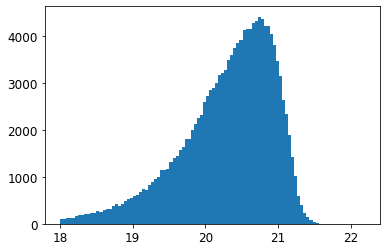

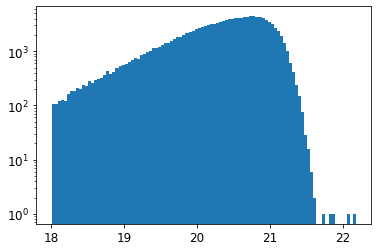

In [23]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100)
plt.show()

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True)
plt.show()

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])

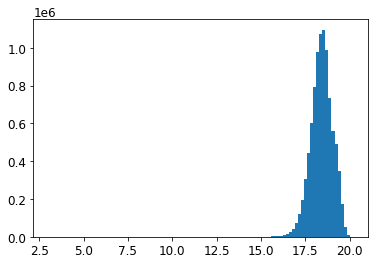

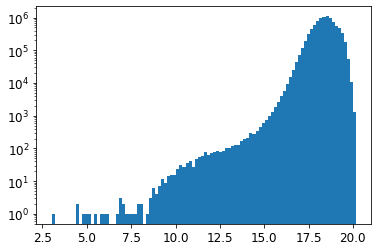

In [25]:
plt.hist(cat['w1mag'], 100)
plt.show()

plt.hist(cat['w1mag'], 100, log=True)
plt.show()

0.07294099377353652


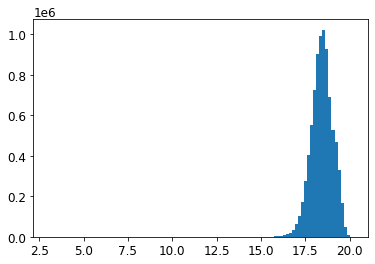

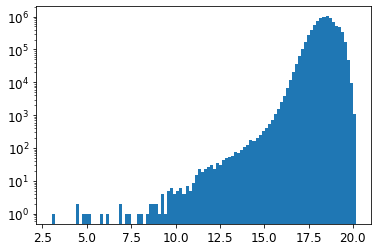

In [41]:
maskbits = [11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

plt.hist(cat['w1mag'][mask_clean], 100)
plt.show()

plt.hist(cat['w1mag'][mask_clean], 100, log=True)
plt.show()

0.06424603580366874


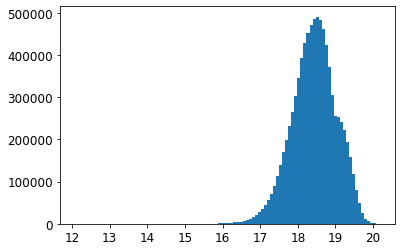

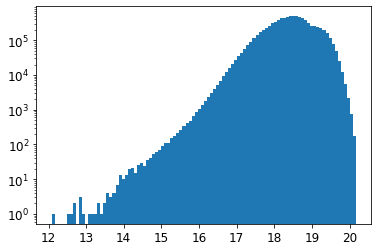

In [45]:
maskbits = [8, 9]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

plt.hist(cat['w1mag'][mask_clean], 100)
plt.show()

plt.hist(cat['w1mag'][mask_clean], 100, log=True)
plt.show()

In [38]:
mask = cat['w1mag']<9
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

38 (0.000%)


In [39]:
mask = cat['w1mag']<13
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

1119 (0.012%)


In [46]:
mask = cat['w1mag']<15
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

4006 (0.044%)


__All W1_AB<13 "LRGs" are imaging artifacts__

-------
# ELG

In [7]:
target_class = 'elg'
cat0 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_basic.fits'.format(target_class)))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_photom.fits'.format(target_class), columns=['GAIA_PHOT_G_MEAN_MAG']))
cat = hstack([cat0, cat], join_type='exact')
print(len(cat))

35360631


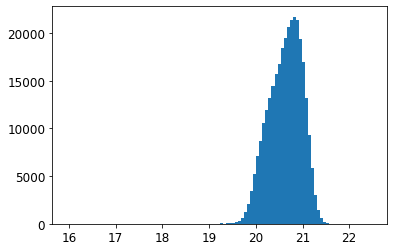

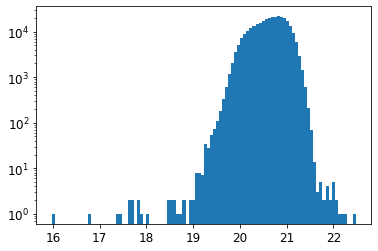

In [8]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100)
plt.show()

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True)
plt.show()

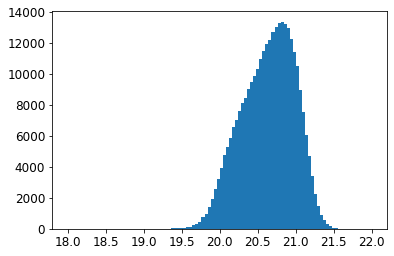

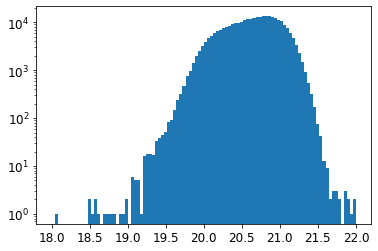

In [9]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, range=(18, 22))
plt.show()

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True, range=(18, 22))
plt.show()

In [11]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<18
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

11 (0.000%)


In [12]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<19
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

26 (0.000%)


In [13]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<20
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

12429 (0.035%)


-------
# QSO

In [14]:
target_class = 'qso'
cat0 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_basic.fits'.format(target_class)))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_photom.fits'.format(target_class), columns=['FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'GAIA_PHOT_G_MEAN_MAG']))
cat = hstack([cat0, cat], join_type='exact')
print(len(cat))

4677998


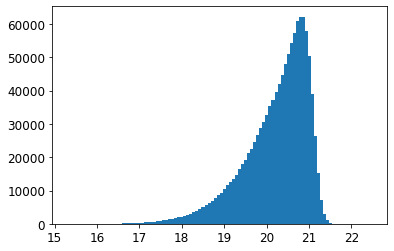

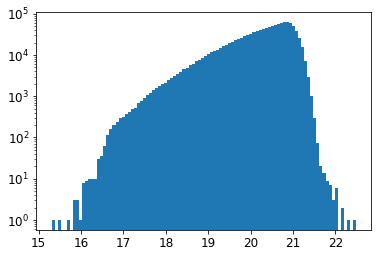

In [15]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100)
plt.show()

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True)
plt.show()

In [16]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<16
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

10 (0.000%)


In [17]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<17
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

1378 (0.029%)


In [18]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<18
print('{} ({:.3f}%)'.format(np.sum(mask), np.sum(mask)/len(mask)*100))

15688 (0.335%)


In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])

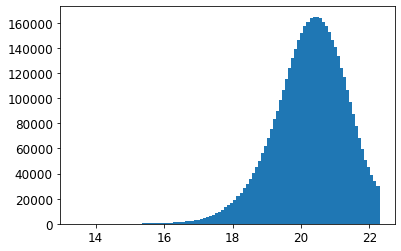

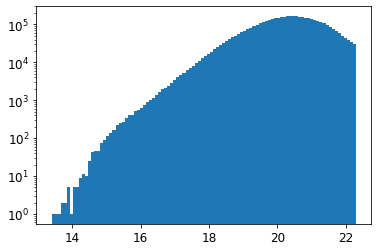

In [20]:
plt.hist(cat['w1mag'], 100)
plt.show()

plt.hist(cat['w1mag'], 100, log=True)
plt.show()

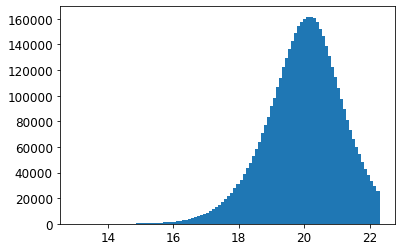

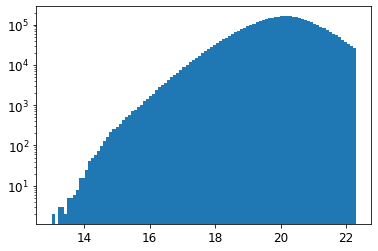

In [21]:
plt.hist(cat['w2mag'], 100)
plt.show()

plt.hist(cat['w2mag'], 100, log=True)
plt.show()